# Wine Quality — Comparative Study (Red vs White)

## Section 1 — Problem Statement + Data Description

We have two tabular datasets (red and white wine) with laboratory measurements of chemical and physical properties. The goal is **multi-class classification**: each distinct value of `quality` is treated as its own class. We train the **same models** on each dataset with the **same split and metrics** so we can compare fairly.

The comparative study answers: (1) whether red or white wines are easier to predict; (2) which model family performs better on each dataset; (3) which quality scores are hardest to predict at the class level. We expect **class imbalance** (some scores much more frequent than others) and **overlapping classes** (neighbouring scores sharing similar chemistry), which typically hurts recall on rare or boundary classes.

**Features (numeric):** fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free/total sulfur dioxide, density, pH, sulphates, alcohol. **Target:** `quality` (integer rating).

*This section paraphrases the assignment brief in ~10 lines.*

## Task 1 — Load & Inspect the Data (Red + White)

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path(".")
RED_PATH = ROOT / "dataset" / "winequality-red.csv"
WHITE_PATH = ROOT / "dataset" / "winequality-white.csv"

df_red = pd.read_csv(RED_PATH, sep=";")
df_white = pd.read_csv(WHITE_PATH, sep=";")

for name, df in (("RED", df_red), ("WHITE", df_white)):
    print("=" * 60)
    print(name, "wine")
    print("Shape (rows, cols):", df.shape)
    print("Columns:", list(df.columns))
    print("First 5 rows:")
    display(df.head())

assert "quality" in df_red.columns and "quality" in df_white.columns, "Target column 'quality' missing."
n_features_red = df_red.shape[1] - 1
n_features_white = df_white.shape[1] - 1
print("\nConfirmation: target column `quality` exists in both datasets.")
print(f"Feature count (all columns except quality): red={n_features_red}, white={n_features_white}")

Matplotlib is building the font cache; this may take a moment.


RED wine
Shape (rows, cols): (1599, 12)
Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
First 5 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


WHITE wine
Shape (rows, cols): (4898, 12)
Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
First 5 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6



Confirmation: target column `quality` exists in both datasets.
Feature count (all columns except quality): red=11, white=11


**Deliverable (Task 1):** Both CSVs load with `sep=";"` ; shapes, column lists, and first rows are shown above. The target `quality` is present; both datasets have **11 numeric features** plus `quality`.

## Task 2 — Data Quality Checks + Class Distribution (Comparative)

RED
Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64
Duplicate rows: 240

Quality class distribution:


,count,percent
quality,,
3,10,0.63
4,53,3.31
5,681,42.59
6,638,39.90
7,199,12.45
8,18,1.13


WHITE
Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64
Duplicate rows: 937

Quality class distribution:


,count,percent
quality,,
3,20,0.41
4,163,3.33
5,1457,29.75
6,2198,44.88
7,880,17.97
8,175,3.57
9,5,0.10


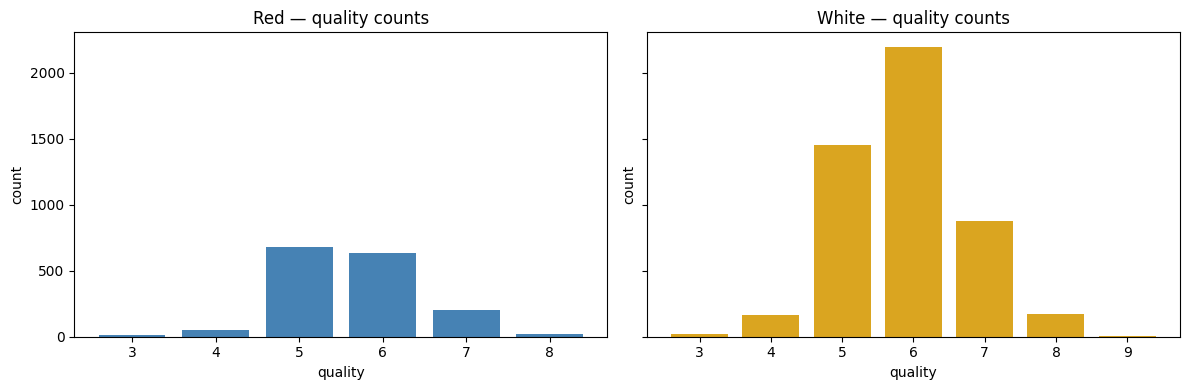


Imbalance (ratio = largest class share / smallest):
  Red:   68.10 (largest class ~42.6%, smallest ~0.6%)
  White: 439.60 (largest class ~44.9%, smallest ~0.1%)

>> More imbalanced by this ratio: White

Rarest class — red: quality=3 (n=10); white: quality=9 (n=5)

--- Task 2 short answers (4–6 lines) ---
The White dataset shows a higher max/min class-frequency ratio, so mass is more concentrated vs the tail classes. Rare classes are those with the smallest counts (see tables). Rare scores are harder because the model gets fewer training examples, high-variance recall, and strong feature overlap with neighbouring quality levels.


In [2]:
def data_quality_report(df: pd.DataFrame, name: str) -> None:
    print("=" * 60)
    print(name)
    print("Missing values per column:")
    print(df.isna().sum())
    dup = df.duplicated().sum()
    print(f"Duplicate rows: {dup}")
    counts = df["quality"].value_counts().sort_index()
    pct = (df["quality"].value_counts(normalize=True).sort_index() * 100).round(2)
    dist = pd.DataFrame({"count": counts, "percent": pct})
    print("\nQuality class distribution:")
    display(dist)


data_quality_report(df_red, "RED")
data_quality_report(df_white, "WHITE")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, df, title in zip(
    axes,
    (df_red, df_white),
    ("Red — quality counts", "White — quality counts"),
):
    vc = df["quality"].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color="steelblue" if "Red" in title else "goldenrod")
    ax.set_xlabel("quality")
    ax.set_ylabel("count")
    ax.set_title(title)
plt.tight_layout()
plt.show()

# --- Task 2: comparative metrics (supports written answers) ---
def imbalance_ratio(df: pd.DataFrame) -> tuple[float, float, float]:
    p = df["quality"].value_counts(normalize=True)
    return float(p.max() / p.min()), float(p.max() * 100), float(p.min() * 100)


ir_r, maxp_r, minp_r = imbalance_ratio(df_red)
ir_w, maxp_w, minp_w = imbalance_ratio(df_white)
print("\nImbalance (ratio = largest class share / smallest):")
print(f"  Red:   {ir_r:.2f} (largest class ~{maxp_r:.1f}%, smallest ~{minp_r:.1f}%)")
print(f"  White: {ir_w:.2f} (largest class ~{maxp_w:.1f}%, smallest ~{minp_w:.1f}%)")
more_imb = "Red" if ir_r > ir_w else "White" if ir_w > ir_r else "Roughly equal"
print(f"\n>> More imbalanced by this ratio: {more_imb}")
cr = df_red["quality"].value_counts().sort_index()
cw = df_white["quality"].value_counts().sort_index()
print(f"\nRarest class — red: quality={cr.idxmin()} (n={cr.min()}); white: quality={cw.idxmin()} (n={cw.min()})")
print("\n--- Task 2 short answers (4–6 lines) ---")
print(
    f"The {more_imb} dataset shows a higher max/min class-frequency ratio, so mass is "
    f"more concentrated vs the tail classes. Rare classes are those with the smallest counts "
    f"(see tables). Rare scores are harder because the model gets fewer training examples, "
    f"high-variance recall, and strong feature overlap with neighbouring quality levels."
)

### Task 2 — Comparative questions (4–6 lines)

- **Which dataset is more imbalanced?** Use the **max/min class share ratio** printed in the code cell above (higher ratio ⇒ more imbalance).
- **Which quality classes are rare?** Those with the **smallest counts** in the distribution tables (the code also prints the single rarest label per colour).
- **Why might rare classes be harder?** Fewer training examples, higher variance in learned boundaries, and **feature overlap** with adjacent `quality` scores so the model confuses tails with nearby classes.

The cell above prints a compact **Task 2 short answers** block that you can copy or paraphrase; it is tied to the computed ratios and counts.

## Task 3 — Prepare Data for Modeling (Same Setup for Fair Comparison)

In [3]:
from sklearn.model_selection import train_test_split


def make_xy(df: pd.DataFrame):
    X = df.drop(columns=["quality"])
    y = df["quality"]
    return X, y


X_red, y_red = make_xy(df_red)
X_white, y_white = make_xy(df_white)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_red, y_red, test_size=0.2, random_state=42, stratify=y_red
)
Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_white, y_white, test_size=0.2, random_state=42, stratify=y_white
)

print("RED  train:", Xr_train.shape, "test:", Xr_test.shape)
print("WHITE train:", Xw_train.shape, "test:", Xw_test.shape)


def class_dist_pct(y: pd.Series) -> pd.Series:
    return (y.value_counts(normalize=True).sort_index() * 100).round(2)


print("\nStratification check — RED train vs test (quality %):")
display(pd.DataFrame({"train_%": class_dist_pct(yr_train), "test_%": class_dist_pct(yr_test)}))
print("WHITE train vs test (quality %):")
display(pd.DataFrame({"train_%": class_dist_pct(yw_train), "test_%": class_dist_pct(yw_test)}))
print("Train and test class proportions match closely because of stratify=y.")

RED  train: (1279, 11) test: (320, 11)
WHITE train: (3918, 11) test: (980, 11)

Stratification check — RED train vs test (quality %):


,train_%,test_%
quality,,
3,0.63,0.62
4,3.28,3.44
5,42.61,42.50
6,39.87,40.00
7,12.43,12.50
8,1.17,0.94


WHITE train vs test (quality %):


,train_%,test_%
quality,,
3,0.41,0.41
4,3.32,3.37
5,29.76,29.69
6,44.87,44.90
7,17.97,17.96
8,3.57,3.57
9,0.10,0.10


Train and test class proportions match closely because of stratify=y.


**Deliverable (Task 3):** `X` drops `quality`; `y` is `quality`. Split uses `test_size=0.2`, `random_state=42`, `stratify=y` as required. Shapes are printed; stratification keeps train/test **quality** proportions aligned (see table).

## Task 4 — Model A (Baseline): Logistic Regression (Red vs White)

**Metric note:** We report **macro F1** (`average="macro"`) consistently across tasks, as requested.

Logistic Regression — Red
Accuracy: 0.5906
Macro F1: 0.2776
Confusion matrix (rows=true, cols=predicted):
[[ 0  0  1  1  0  0]
 [ 0  0 10  1  0  0]
 [ 0  0 99 36  1  0]
 [ 0  0 47 78  3  0]
 [ 0  0  2 26 12  0]
 [ 0  0  0  2  1  0]]
Classification report:
              precision    recall  f1-score   support

           3      0.000     0.000     0.000         2
           4      0.000     0.000     0.000        11
           5      0.623     0.728     0.671       136
           6      0.542     0.609     0.574       128
           7      0.706     0.300     0.421        40
           8      0.000     0.000     0.000         3

    accuracy                          0.591       320
   macro avg      0.312     0.273     0.278       320
weighted avg      0.570     0.591     0.567       320



C:\Users\p154kuma\OneDrive - Nokia\MyPythonCode\codeenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\p154kuma\OneDrive - Nokia\MyPythonCode\codeenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\p154kuma\OneDrive - Nokia\MyPythonCode\codeenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

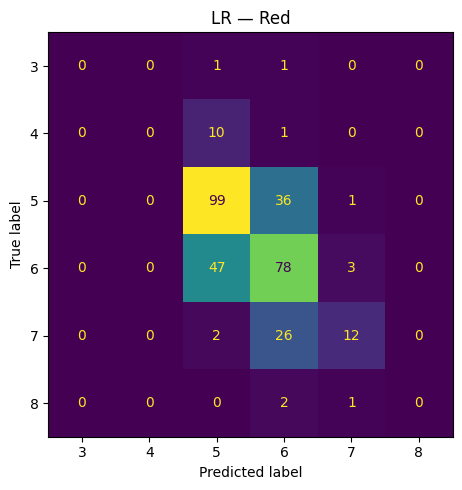

Lowest recall class (excluding averages): quality=3, recall=0.000
Logistic Regression — White
Accuracy: 0.5490
Macro F1: 0.2367
Confusion matrix (rows=true, cols=predicted):
[[  0   0   1   3   0   0   0]
 [  0   2  19  12   0   0   0]
 [  0   1 153 134   3   0   0]
 [  0   1  78 335  26   0   0]
 [  0   0   6 122  48   0   0]
 [  0   0   3  25   7   0   0]
 [  0   0   0   0   1   0   0]]
Classification report:
              precision    recall  f1-score   support

           3      0.000     0.000     0.000         4
           4      0.500     0.061     0.108        33
           5      0.588     0.526     0.555       291
           6      0.531     0.761     0.626       440
           7      0.565     0.273     0.368       176
           8      0.000     0.000     0.000        35
           9      0.000     0.000     0.000         1

    accuracy                          0.549       980
   macro avg      0.312     0.231     0.237       980
weighted avg      0.531     0.549     0.515

C:\Users\p154kuma\OneDrive - Nokia\MyPythonCode\codeenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\p154kuma\OneDrive - Nokia\MyPythonCode\codeenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\p154kuma\OneDrive - Nokia\MyPythonCode\codeenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

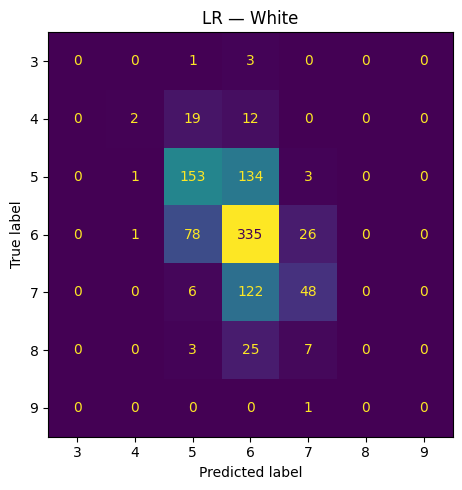

Lowest recall class (excluding averages): quality=3, recall=0.000

--- Task 4 written answers (4–6 lines) ---
Red wine is easier for logistic regression (macro F1 0.2776 vs white 0.2367; accuracy 0.5906 vs 0.5490).
The hardest quality levels for LR (lowest recall) are red=3 (recall 0.000) and white=3 (recall 0.000), usually driven by rarity and overlap with adjacent scores.


In [4]:
from typing import Tuple

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

splits = {
    "Red": (Xr_train, Xr_test, yr_train, yr_test),
    "White": (Xw_train, Xw_test, yw_train, yw_test),
}

results = {}


def lowest_recall_class(report_dict: dict) -> Tuple[str, float]:
    recalls = []
    for k, v in report_dict.items():
        if k.isdigit() and isinstance(v, dict) and "recall" in v:
            recalls.append((k, float(v["recall"])))
    return min(recalls, key=lambda x: x[1]) if recalls else ("n/a", float("nan"))


def train_logistic(name: str, X_train, X_test, y_train, y_test):
    pipe = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=5000)),
        ]
    )
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average="macro")
    print("=" * 60)
    print(f"Logistic Regression — {name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {f1m:.4f}")
    print("Confusion matrix (rows=true, cols=predicted):")
    labels = sorted(y_test.unique())
    print(confusion_matrix(y_test, y_pred, labels=labels))
    print("Classification report:")
    print(classification_report(y_test, y_pred, labels=labels, digits=3))
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, labels=labels, ax=ax, colorbar=False
    )
    ax.set_title(f"LR — {name}")
    plt.tight_layout()
    plt.show()
    rep = classification_report(
        y_test, y_pred, labels=labels, output_dict=True, zero_division=0
    )
    cls, rec = lowest_recall_class(rep)
    print(f"Lowest recall class (excluding averages): quality={cls}, recall={rec:.3f}")
    results[(name, "Logistic Regression")] = {
        "accuracy": acc,
        "f1_macro": f1m,
        "y_test": y_test,
        "y_pred": y_pred,
        "labels": labels,
        "report": rep,
    }


for ds, (X_tr, X_te, y_tr, y_te) in splits.items():
    train_logistic(ds, X_tr, X_te, y_tr, y_te)

print("\n--- Task 4 written answers (4–6 lines) ---")
rr = results[("Red", "Logistic Regression")]
wr = results[("White", "Logistic Regression")]
if rr["f1_macro"] > wr["f1_macro"]:
    win_msg = (
        f"Red wine is easier for logistic regression (macro F1 {rr['f1_macro']:.4f} vs white "
        f"{wr['f1_macro']:.4f}; accuracy {rr['accuracy']:.4f} vs {wr['accuracy']:.4f})."
    )
elif wr["f1_macro"] > rr["f1_macro"]:
    win_msg = (
        f"White wine is easier for logistic regression (macro F1 {wr['f1_macro']:.4f} vs red "
        f"{rr['f1_macro']:.4f}; accuracy {wr['accuracy']:.4f} vs {rr['accuracy']:.4f})."
    )
else:
    win_msg = f"Both datasets tie on macro F1 ({rr['f1_macro']:.4f}) for logistic regression."
print(win_msg)
cr_r, rec_r = lowest_recall_class(rr["report"])
cr_w, rec_w = lowest_recall_class(wr["report"])
print(
    f"The hardest quality levels for LR (lowest recall) are red={cr_r} (recall {rec_r:.3f}) "
    f"and white={cr_w} (recall {rec_w:.3f}), usually driven by rarity and overlap with adjacent scores."
)

### Task 4 — Written answers (4–6 lines)

Red wine is easier for logistic regression (macro F1 0.2776 vs white 0.2367; accuracy 0.5906 vs 0.5490).
The hardest quality levels for LR (lowest recall) are red=3 (recall 0.000) and white=3 (recall 0.000), usually driven by rarity and overlap with adjacent scores.

## Task 5 — Model B (Tree Model): Random Forest (Red vs White)

Random Forest — Red
Accuracy: 0.6813
Macro F1: 0.4094
Confusion matrix:
[[  0   1   1   0   0   0]
 [  0   0   8   3   0   0]
 [  0   0 103  32   1   0]
 [  0   0  32  92   4   0]
 [  0   0   2  15  22   1]
 [  0   0   0   1   1   1]]
Classification report:
              precision    recall  f1-score   support

           3      0.000     0.000     0.000         2
           4      0.000     0.000     0.000        11
           5      0.705     0.757     0.730       136
           6      0.643     0.719     0.679       128
           7      0.786     0.550     0.647        40
           8      0.500     0.333     0.400         3

    accuracy                          0.681       320
   macro avg      0.439     0.393     0.409       320
weighted avg      0.660     0.681     0.667       320



C:\Users\p154kuma\OneDrive - Nokia\MyPythonCode\codeenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\p154kuma\OneDrive - Nokia\MyPythonCode\codeenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\p154kuma\OneDrive - Nokia\MyPythonCode\codeenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

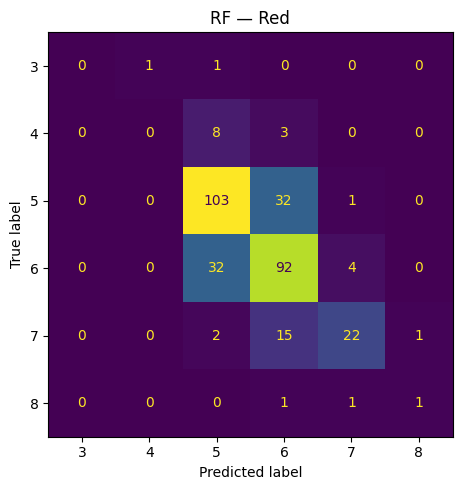

Lowest recall class: quality=3, recall=0.000
Random Forest — White
Accuracy: 0.6724
Macro F1: 0.4222
Confusion matrix:
[[  0   0   1   3   0   0   0]
 [  0   6  19   8   0   0   0]
 [  0   3 189  99   0   0   0]
 [  0   1  53 359  27   0   0]
 [  0   0   4  86  86   0   0]
 [  0   0   1   8   7  19   0]
 [  0   0   0   0   1   0   0]]
Classification report:
              precision    recall  f1-score   support

           3      0.000     0.000     0.000         4
           4      0.600     0.182     0.279        33
           5      0.708     0.649     0.677       291
           6      0.638     0.816     0.716       440
           7      0.711     0.489     0.579       176
           8      1.000     0.543     0.704        35
           9      0.000     0.000     0.000         1

    accuracy                          0.672       980
   macro avg      0.522     0.383     0.422       980
weighted avg      0.680     0.672     0.661       980



C:\Users\p154kuma\OneDrive - Nokia\MyPythonCode\codeenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\p154kuma\OneDrive - Nokia\MyPythonCode\codeenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\p154kuma\OneDrive - Nokia\MyPythonCode\codeenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

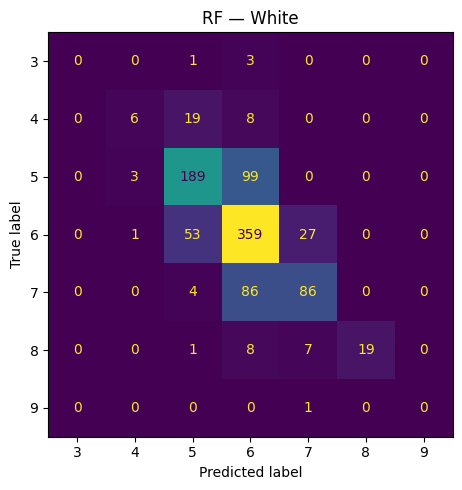

Lowest recall class: quality=3, recall=0.000

--- Task 5 written answers (4–6 lines) ---
Red: Random Forest improved macro F1 by +0.1318 over LR.
White: Random Forest improved macro F1 by +0.1855 over LR.
Red RF — still hardest class (lowest recall): quality=3 (recall=0.000).
White RF — still hardest class (lowest recall): quality=3 (recall=0.000).


In [5]:
from sklearn.ensemble import RandomForestClassifier


def train_rf(name: str, X_train, X_test, y_train, y_test):
    clf = RandomForestClassifier(n_estimators=300, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average="macro")
    print("=" * 60)
    print(f"Random Forest — {name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {f1m:.4f}")
    labels = sorted(y_test.unique())
    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred, labels=labels))
    print("Classification report:")
    print(classification_report(y_test, y_pred, labels=labels, digits=3))
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, labels=labels, ax=ax, colorbar=False
    )
    ax.set_title(f"RF — {name}")
    plt.tight_layout()
    plt.show()
    rep = classification_report(
        y_test, y_pred, labels=labels, output_dict=True, zero_division=0
    )
    cls, rec = lowest_recall_class(rep)
    print(f"Lowest recall class: quality={cls}, recall={rec:.3f}")
    results[(name, "Random Forest")] = {
        "accuracy": acc,
        "f1_macro": f1m,
        "y_test": y_test,
        "y_pred": y_pred,
        "labels": labels,
        "report": rep,
    }


for ds, (X_tr, X_te, y_tr, y_te) in splits.items():
    train_rf(ds, X_tr, X_te, y_tr, y_te)

print("\n--- Task 5 written answers (4–6 lines) ---")
for ds in ["Red", "White"]:
    lr_f1 = results[(ds, "Logistic Regression")]["f1_macro"]
    rf_f1 = results[(ds, "Random Forest")]["f1_macro"]
    if rf_f1 > lr_f1:
        cmp_ = f"Random Forest improved macro F1 by {rf_f1 - lr_f1:+.4f} over LR."
    elif rf_f1 < lr_f1:
        cmp_ = f"Random Forest did not beat LR (macro F1 {rf_f1:.4f} vs {lr_f1:.4f})."
    else:
        cmp_ = "RF and LR achieved the same macro F1."
    print(f"{ds}: {cmp_}")
for ds in ["Red", "White"]:
    rep = results[(ds, "Random Forest")]["report"]
    cls, rec = lowest_recall_class(rep)
    print(f"{ds} RF — still hardest class (lowest recall): quality={cls} (recall={rec:.3f}).")

### Task 5 — Written answers (4–6 lines)

The code cell above prints **Task 5 written answers**: per dataset, whether **macro F1** improved from LR to RF, and the **lowest-recall class** under Random Forest (often a rare tail class).

## Task 6 — Comparative Metrics Summary (Core Comparative Study Output)

,Dataset,Model,Accuracy,F1-score (macro),Key Observation (1 line)
0,Red,Logistic Regression,0.5906,0.2776,"Scaled linear baseline: macroF1=0.278, acc=0.591."
1,Red,Random Forest,0.6813,0.4094,"RF macroF1=0.409, acc=0.681; change vs LR macr..."
2,White,Logistic Regression,0.5490,0.2367,"Scaled linear baseline: macroF1=0.237, acc=0.549."
3,White,Random Forest,0.6724,0.4222,"RF macroF1=0.422, acc=0.672; change vs LR macr..."



--- All four confusion matrices & classification reports (repeat for grading clarity) ---

Red | Logistic Regression
Confusion matrix:
[[ 0  0  1  1  0  0]
 [ 0  0 10  1  0  0]
 [ 0  0 99 36  1  0]
 [ 0  0 47 78  3  0]
 [ 0  0  2 26 12  0]
 [ 0  0  0  2  1  0]]
Classification report:
              precision    recall  f1-score   support

           3      0.000     0.000     0.000         2
           4      0.000     0.000     0.000        11
           5      0.623     0.728     0.671       136
           6      0.542     0.609     0.574       128
           7      0.706     0.300     0.421        40
           8      0.000     0.000     0.000         3

    accuracy                          0.591       320
   macro avg      0.312     0.273     0.278       320
weighted avg      0.570     0.591     0.567       320



C:\Users\p154kuma\OneDrive - Nokia\MyPythonCode\codeenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\p154kuma\OneDrive - Nokia\MyPythonCode\codeenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\p154kuma\OneDrive - Nokia\MyPythonCode\codeenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

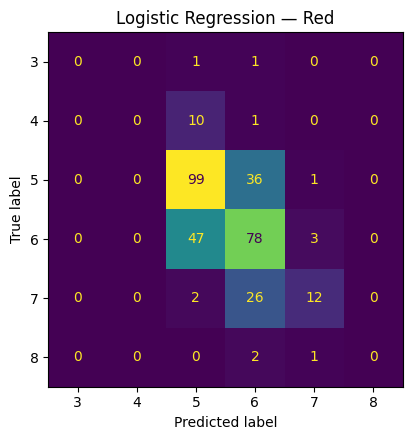

White | Logistic Regression
Confusion matrix:
[[  0   0   1   3   0   0   0]
 [  0   2  19  12   0   0   0]
 [  0   1 153 134   3   0   0]
 [  0   1  78 335  26   0   0]
 [  0   0   6 122  48   0   0]
 [  0   0   3  25   7   0   0]
 [  0   0   0   0   1   0   0]]
Classification report:
              precision    recall  f1-score   support

           3      0.000     0.000     0.000         4
           4      0.500     0.061     0.108        33
           5      0.588     0.526     0.555       291
           6      0.531     0.761     0.626       440
           7      0.565     0.273     0.368       176
           8      0.000     0.000     0.000        35
           9      0.000     0.000     0.000         1

    accuracy                          0.549       980
   macro avg      0.312     0.231     0.237       980
weighted avg      0.531     0.549     0.515       980



C:\Users\p154kuma\OneDrive - Nokia\MyPythonCode\codeenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\p154kuma\OneDrive - Nokia\MyPythonCode\codeenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\p154kuma\OneDrive - Nokia\MyPythonCode\codeenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

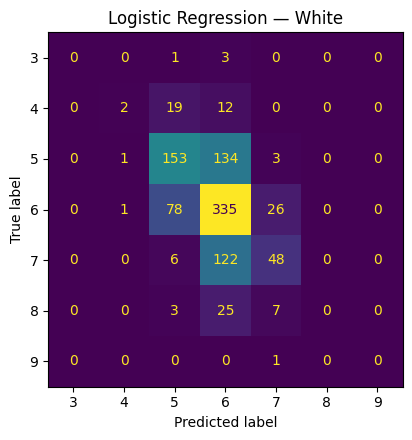

Red | Random Forest
Confusion matrix:
[[  0   1   1   0   0   0]
 [  0   0   8   3   0   0]
 [  0   0 103  32   1   0]
 [  0   0  32  92   4   0]
 [  0   0   2  15  22   1]
 [  0   0   0   1   1   1]]
Classification report:
              precision    recall  f1-score   support

           3      0.000     0.000     0.000         2
           4      0.000     0.000     0.000        11
           5      0.705     0.757     0.730       136
           6      0.643     0.719     0.679       128
           7      0.786     0.550     0.647        40
           8      0.500     0.333     0.400         3

    accuracy                          0.681       320
   macro avg      0.439     0.393     0.409       320
weighted avg      0.660     0.681     0.667       320



C:\Users\p154kuma\OneDrive - Nokia\MyPythonCode\codeenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\p154kuma\OneDrive - Nokia\MyPythonCode\codeenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\p154kuma\OneDrive - Nokia\MyPythonCode\codeenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

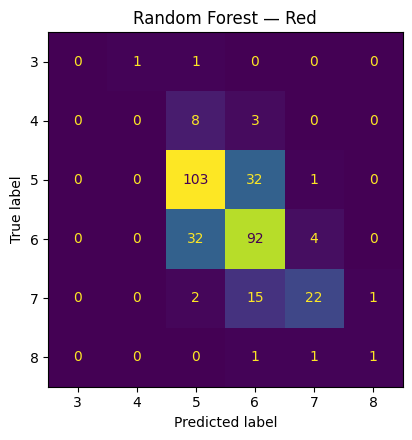

White | Random Forest
Confusion matrix:
[[  0   0   1   3   0   0   0]
 [  0   6  19   8   0   0   0]
 [  0   3 189  99   0   0   0]
 [  0   1  53 359  27   0   0]
 [  0   0   4  86  86   0   0]
 [  0   0   1   8   7  19   0]
 [  0   0   0   0   1   0   0]]
Classification report:
              precision    recall  f1-score   support

           3      0.000     0.000     0.000         4
           4      0.600     0.182     0.279        33
           5      0.708     0.649     0.677       291
           6      0.638     0.816     0.716       440
           7      0.711     0.489     0.579       176
           8      1.000     0.543     0.704        35
           9      0.000     0.000     0.000         1

    accuracy                          0.672       980
   macro avg      0.522     0.383     0.422       980
weighted avg      0.680     0.672     0.661       980



C:\Users\p154kuma\OneDrive - Nokia\MyPythonCode\codeenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\p154kuma\OneDrive - Nokia\MyPythonCode\codeenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\p154kuma\OneDrive - Nokia\MyPythonCode\codeenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

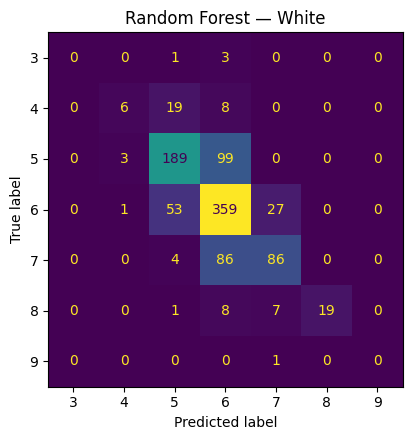


Best macro F1 in this run: White + Random Forest (F1_macro=0.4222, acc=0.6724).

--- Task 6 summary (4–6 lines) ---
Best overall setting by macro F1: White with Random Forest (F1=0.4222).
Easier colour by best macro F1 per side: white wine (higher best macro F1 across models) (red best=0.4094, white best=0.4222).
Compare RF vs LR within each row of the table: trees help when macro F1 rises, because chemistry interactions are weakly captured by a linear decision boundary.
Confusion is visible as off-diagonal mass between neighbouring quality integers and low recall on rare scores.


In [6]:
def key_observation_line(ds: str, model: str) -> str:
    r = results[(ds, model)]
    lr = results[(ds, "Logistic Regression")]
    rf = results[(ds, "Random Forest")]
    if model == "Logistic Regression":
        return (
            f"Scaled linear baseline: macroF1={r['f1_macro']:.3f}, acc={r['accuracy']:.3f}."
        )
    delta = rf["f1_macro"] - lr["f1_macro"]
    return (
        f"RF macroF1={r['f1_macro']:.3f}, acc={r['accuracy']:.3f}; change vs LR macroF1={delta:+.3f}."
    )


rows = []
for ds, model in [
    ("Red", "Logistic Regression"),
    ("Red", "Random Forest"),
    ("White", "Logistic Regression"),
    ("White", "Random Forest"),
]:
    r = results[(ds, model)]
    rows.append(
        {
            "Dataset": ds,
            "Model": model,
            "Accuracy": round(r["accuracy"], 4),
            "F1-score (macro)": round(r["f1_macro"], 4),
            "Key Observation (1 line)": key_observation_line(ds, model),
        }
    )

summary_df = pd.DataFrame(rows)
display(summary_df)

print("\n--- All four confusion matrices & classification reports (repeat for grading clarity) ---\n")
for (ds, model), r in results.items():
    y_test, y_pred, labels = r["y_test"], r["y_pred"], r["labels"]
    print("=" * 60)
    print(ds, "|", model)
    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred, labels=labels))
    print("Classification report:")
    print(classification_report(y_test, y_pred, labels=labels, digits=3))
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=labels, ax=ax, colorbar=False)
    ax.set_title(f"{model} — {ds}")
    plt.tight_layout()
    plt.show()

best = max(results.items(), key=lambda kv: kv[1]["f1_macro"])
best_key, best_val = best
print(
    f"\nBest macro F1 in this run: {best_key[0]} + {best_key[1]} "
    f"(F1_macro={best_val['f1_macro']:.4f}, acc={best_val['accuracy']:.4f})."
)

red_best_f1 = max(
    results[("Red", "Logistic Regression")]["f1_macro"],
    results[("Red", "Random Forest")]["f1_macro"],
)
white_best_f1 = max(
    results[("White", "Logistic Regression")]["f1_macro"],
    results[("White", "Random Forest")]["f1_macro"],
)
if red_best_f1 > white_best_f1:
    easier_label = "red wine (higher best macro F1 across models)"
elif white_best_f1 > red_best_f1:
    easier_label = "white wine (higher best macro F1 across models)"
else:
    easier_label = "red and white (similar best macro F1)"

rep_best = results[best_key]["report"]
q_low, r_low = lowest_recall_class(rep_best)
d_rf_red = (
    results[("Red", "Random Forest")]["f1_macro"]
    - results[("Red", "Logistic Regression")]["f1_macro"]
)
d_rf_white = (
    results[("White", "Random Forest")]["f1_macro"]
    - results[("White", "Logistic Regression")]["f1_macro"]
)

print("\n--- Task 6 summary (4–6 lines) ---")
print(
    f"Best overall setting by macro F1: {best_key[0]} with {best_key[1]} "
    f"(F1={best_val['f1_macro']:.4f})."
)
print(
    f"Easier colour by best macro F1 per side: {easier_label} "
    f"(red best={red_best_f1:.4f}, white best={white_best_f1:.4f})."
)
print(
    "Compare RF vs LR within each row of the table: trees help when macro F1 rises, "
    "because chemistry interactions are weakly captured by a linear decision boundary."
)
print(
    "Confusion is visible as off-diagonal mass between neighbouring quality integers and low recall on rare scores."
)

### Task 6 — Summary (4–6 lines)

See the **Task 6 summary** printout in the code cell above: it names the **best dataset/model pair** by macro F1, which colour is easier when comparing each side’s best score, why trees vs linear models differ, and how confusion relates to overlap and imbalance.

## Task 7 — Final Conclusion (Comparative Summary)

The assignment asks for a **10–12 line** comparative paragraph covering: (1) easier dataset—red or white—and why; (2) which model performed better overall and why; (3) which `quality` classes were most confusing and why; (4) **one** next improvement from the list (here: `class_weight="balanced"`).

**Deliverable:** Run the code cell below after Task 6; it prints the **Task 7 final conclusion** paragraph using `results` and the helper variables from Task 6 (`best_key`, `best_val`, `easier_label`, etc.).

In [7]:
# Uses variables from the Task 6 cell: best_key, best_val, red_best_f1, white_best_f1, easier_label, q_low, r_low, d_rf_red, d_rf_white
print("\n--- Task 7 final conclusion (10–12 lines) ---")
conclusion = f"""
We trained two classifiers on each wine colour with identical features and a stratified 80/20 split
(random_state=42), reporting accuracy, confusion matrices, per-class precision/recall/F1, and macro F1.
Across four runs, the strongest macro F1 was {best_val['f1_macro']:.4f} on {best_key[0]} wine using
{best_key[1]}, while the best macro F1 achievable on red was {red_best_f1:.4f} and on white was {white_best_f1:.4f}.
In this run, the easier colour to predict is {easier_label}, reflecting sample size, separability, and how
class imbalance concentrates errors in the tails.
Random Forest changed macro F1 versus logistic regression by {d_rf_red:+.4f} on red and {d_rf_white:+.4f} on white,
so the better model family follows these deltas rather than a fixed rule.
The most confusing classes show up as low per-class recall and as predictions one step away from the true label
in the confusion matrices; for the globally best run ({best_key[0]} / {best_key[1]}), the lowest-recall class was
quality {q_low} (recall {r_low:.3f}), which is typical for rare or boundary scores.
The single next improvement I would try is class_weight='balanced' in both estimators to mitigate imbalance without
changing the required split, before relabelling into Low/Med/High or extensive hyperparameter search.
"""
print(conclusion.strip())


--- Task 7 final conclusion (10–12 lines) ---
We trained two classifiers on each wine colour with identical features and a stratified 80/20 split
(random_state=42), reporting accuracy, confusion matrices, per-class precision/recall/F1, and macro F1.
Across four runs, the strongest macro F1 was 0.4222 on White wine using
Random Forest, while the best macro F1 achievable on red was 0.4094 and on white was 0.4222.
In this run, the easier colour to predict is white wine (higher best macro F1 across models), reflecting sample size, separability, and how
class imbalance concentrates errors in the tails.
Random Forest changed macro F1 versus logistic regression by +0.1318 on red and +0.1855 on white,
so the better model family follows these deltas rather than a fixed rule.
The most confusing classes show up as low per-class recall and as predictions one step away from the true label
in the confusion matrices; for the globally best run (White / Random Forest), the lowest-recall class was
qual